# 1) Importing Libraries

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Conv2D, MaxPool2D, 
                                     BatchNormalization, Flatten, GlobalAveragePooling2D, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.applications import EfficientNetB7, MobileNetV2, VGG19, DenseNet121

# 2) Helper Functions & Hyperparameters

In [3]:
def directory_to_df(path : str):
 
    df = []
    chars = 'abcdefghijklmnopqrstuvwxyz'
    for cls in os.listdir(path):
        cls_path = os.path.join(path,cls)
        cls_name = cls.split('_')[0]
        if not cls_name in chars:
            continue
        for img_path in os.listdir(cls_path):
            direct = os.path.join(cls_path,img_path)
            df.append([direct,cls_name])
    
    df = pd.DataFrame(df, columns=['image','label'])
    print("The number of samples found:",len(df))
    return df.copy()

def read_image(path):
    """
    Read an image from specified directory
    _____________________________________________________________
    Arguments:
    
    path: String -> a directory of the image
    _____________________________________________________________
    Return:
    
    image: numpy.array of the image
    """
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def show_image(img, label=None) -> None:
 
    plt.imshow(img, cmap='gray')
    plt.axis(False)
    plt.title(label)
    plt.show()
    
def clbck(model_name):
    # The function is defined to make the callbacks for training the models
    ERLY = EarlyStopping(patience=10, min_delta=0.01, start_from_epoch=10, verbose=1)
    RD = ReduceLROnPlateau(patience=5, min_delta=0.01, factor=0.5)
    CHK = ModelCheckpoint(f'{model_name}_model.h5',verbose=1, save_best_only=True)
    return [ERLY,RD,CHK]

In [4]:
# Pre-defined hyperparameters
IMG_SHAPE = (32,32)
IMG_SIZE = (32,32,3)
BATCH_SIZE = 32
opt = Adam(learning_rate=0.00001, epsilon=1e-6)
loss = 'categorical_crossentropy'
EPOCHS = 10

# 3) Preparing the dataset

In [143]:
# Reading the dataset in dataframe 
main_path = '/kaggle/input/ocr-dataset/dataset'
df = directory_to_df(main_path)     # convert the dataset into df of two columns
df.head()

The number of samples found: 85199


,image,label
0,/kaggle/input/ocr-dataset/dataset/c_L/C_L_1241...,c
1,/kaggle/input/ocr-dataset/dataset/c_L/C_L_3096...,c
2,/kaggle/input/ocr-dataset/dataset/c_L/C_L_3184...,c
3,/kaggle/input/ocr-dataset/dataset/c_L/C_L_2981...,c
4,/kaggle/input/ocr-dataset/dataset/c_L/C_L_1635...,c


In [147]:
df.sample(10)

,image,label
31660,/kaggle/input/ocr-dataset/dataset/t_L/T_L_634.png,t
57783,/kaggle/input/ocr-dataset/dataset/e_L/E_L_3194...,e
19480,/kaggle/input/ocr-dataset/dataset/l_L/L_L_2298...,l
41897,/kaggle/input/ocr-dataset/dataset/k_L/K_L_563.png,k
9368,/kaggle/input/ocr-dataset/dataset/p_L/P_L_2487...,p
3928,/kaggle/input/ocr-dataset/dataset/i_L/I_L_2082...,i
6922,/kaggle/input/ocr-dataset/dataset/p_L/P_L_1886...,p
47092,/kaggle/input/ocr-dataset/dataset/o_L/O_L_379.png,o
84406,/kaggle/input/ocr-dataset/dataset/n_L/N_L_1028...,n
60642,/kaggle/input/ocr-dataset/dataset/y_L/Y_L_1166...,y


In [6]:
df['label'].value_counts()

label
r    3284
e    3284
n    3281
a    3281
m    3281
q    3279
u    3278
i    3277
d    3277
y    3276
x    3276
s    3276
l    3276
k    3276
t    3276
g    3275
w    3275
h    3275
z    3275
f    3275
p    3275
o    3275
b    3274
c    3274
j    3274
v    3274
Name: count, dtype: int64

## 3.1) Splitting the dataframe

In [7]:
# Splitting for training & testing (70,30 respectively)
X, y = df['image'], df['label']
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.30, random_state=41)
training_df = pd.concat((X_train,y_train), axis=1)
testing_df = pd.concat((X_test,y_test), axis=1)

In [8]:
# Splitting for training & validation (75,25 respectively) -> the training set size = 52.5%
X, y = training_df['image'], training_df['label']
X_train, X_valid, y_train, y_valid = train_test_split(X,y , test_size=0.25, random_state=41)
training_df = pd.concat((X_train,y_train), axis=1)
validation_df = pd.concat((X_valid,y_valid), axis=1)

In [9]:
# Creating generators
gen = ImageDataGenerator(dtype=np.int32, brightness_range=[0.0,1.0], fill_mode='nearest')
gen2 = ImageDataGenerator(dtype=np.int32, fill_mode='nearest')
train_gen = gen.flow_from_dataframe(training_df, x_col='image',y_col='label', batch_size=BATCH_SIZE, 
                                   target_size=IMG_SHAPE)
valid_gen = gen2.flow_from_dataframe(validation_df, x_col='image', y_col='label', batch_size=BATCH_SIZE, 
                                        target_size=IMG_SHAPE, shuffle=False)
test_gen = gen2.flow_from_dataframe(testing_df, x_col='image', y_col='label', batch_size=BATCH_SIZE, 
                                       target_size=IMG_SHAPE, shuffle=False)

Found 44729 validated image filenames belonging to 26 classes.
Found 14910 validated image filenames belonging to 26 classes.
Found 25560 validated image filenames belonging to 26 classes.


In [10]:
# Making a mapping of the classes and the inverse for later processings
mapping = train_gen.class_indices
mapping_inverse = dict(map(lambda x: tuple(reversed(x)), mapping.items()))

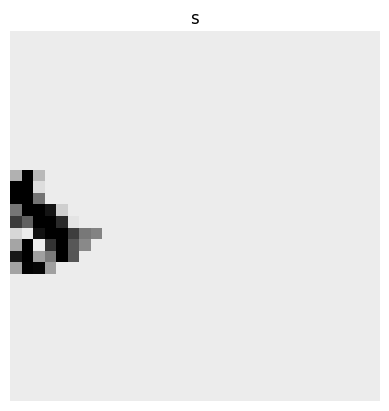

The shape of the image: (32, 32, 3)


In [11]:
# Reading a sample from the dataset
BATCH_NUM = 10
IMG_NUM = 2      # from 0 to 31
show_image(train_gen[BATCH_NUM][0][IMG_NUM],mapping_inverse[train_gen[BATCH_NUM][1][IMG_NUM].argmax()])
print('The shape of the image:',train_gen[BATCH_NUM][0][IMG_NUM].shape)

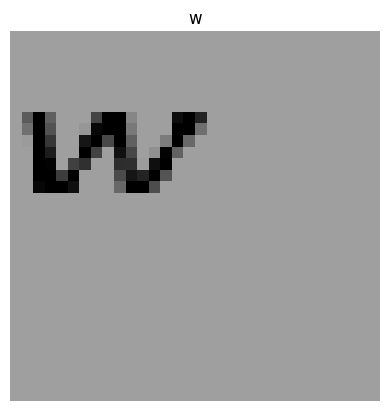

The shape of the image: (32, 32, 3)


In [12]:
# Reading another sample from the dataset
BATCH_NUM = 65
IMG_NUM = 30      # from 0 to 31
show_image(train_gen[BATCH_NUM][0][IMG_NUM],mapping_inverse[train_gen[BATCH_NUM][1][IMG_NUM].argmax()])
print('The shape of the image:',train_gen[BATCH_NUM][0][IMG_NUM].shape)

# 4) Modeling
*Our target is to build a **`custom CNN model`** to train on our targeted images for the `OCR` application. in advance, we also will use 4 Pre-trained models as part of `Transfer Learning` and to enhance the performance of the application.*

***Our targeted pretrained models are the following:***

*- EfficientNetB7*

*- MobileNetV2*

*- VGG19*

*- DenseNet121*

***The fine-tuning strategy:*** *using a small value of `LR` of the optimizer `Adam` will make an efficient use of the pre-trained models on our dataset without **FREEZING** the input layers in which better performance is required in our case*

## 4.1) Custom CNN

In [13]:
# Custom CNN
CNN_model = Sequential()
CNN_model.add(Input(shape=IMG_SIZE, batch_size=BATCH_SIZE, name='Input'))
CNN_model.add(Conv2D(3, (3,3), strides=1, activation='relu', padding='same'))
CNN_model.add(Conv2D(128, (3,3), activation='relu'))
CNN_model.add(MaxPool2D((3,3)))
CNN_model.add(Conv2D(256, (3,3), activation='relu'))
CNN_model.add(Dropout(0.2))
CNN_model.add(Conv2D(256, (3,3), strides=2, activation='relu', padding='same'))
CNN_model.add(MaxPool2D((2,2)))
CNN_model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
CNN_model.add(Dropout(0.2))
CNN_model.add(Conv2D(1024, (2,2), activation='relu', padding='same'))
CNN_model.add(MaxPool2D(2,2))
CNN_model.add(Flatten())
CNN_model.add(Dense(1024, activation='selu'))
CNN_model.add(Dense(len(mapping), activation='softmax'))

In [14]:
CNN_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (32, 32, 32, 3)           84        
                                                                 
 conv2d_1 (Conv2D)           (32, 30, 30, 128)         3584      
                                                                 
 max_pooling2d (MaxPooling2  (32, 10, 10, 128)         0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (32, 8, 8, 256)           295168    
                                                                 
 dropout (Dropout)           (32, 8, 8, 256)           0         
                                                                 
 conv2d_3 (Conv2D)           (32, 4, 4, 256)           590080    
                                                        

In [15]:
# Default parameters of adam will be used for the custom CNN
CNN_model.compile(optimizer=Adam(), loss=loss, metrics=['accuracy'])

In [16]:
# different num. of epochs will be given for better convergence for the Custom CNN
history = CNN_model.fit(train_gen, epochs=20, validation_data=valid_gen, callbacks=clbck("CustomCnn"))

Epoch 1/20


2025-01-18 10:59:26.744590: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1398/1398 [==============================] - ETA: 0s - loss: 1.2926 - accuracy: 0.6534
Epoch 1: val_loss improved from inf to 0.59290, saving model to CustomCnn_model.h5
1398/1398 [==============================] - 489s 345ms/step - loss: 1.2926 - accuracy: 0.6534 - val_loss: 0.5929 - val_accuracy: 0.8665 - lr: 0.0010
Epoch 2/20


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1398/1398 [==============================] - ETA: 0s - loss: 0.4717 - accuracy: 0.8695
Epoch 2: val_loss improved from 0.59290 to 0.47723, saving model to CustomCnn_model.h5
1398/1398 [==============================] - 124s 89ms/step - loss: 0.4717 - accuracy: 0.8695 - val_loss: 0.4772 - val_accuracy: 0.8866 - lr: 0.0010
Epoch 3/20
1398/1398 [==============================] - ETA: 0s - loss: 0.3926 - accuracy: 0.8938
Epoch 3: val_loss improved from 0.47723 to 0.39999, saving model to CustomCnn_model.h5
1398/1398 [==============================] - 99s 71ms/step - loss: 0.3926 - accuracy: 0.8938 - val_loss: 0.4000 - val_accuracy: 0.9033 - lr: 0.0010
Epoch 4/20
1398/1398 [==============================] - ETA: 0s - loss: 0.3479 - accuracy: 0.9058
Epoch 4: val_loss improved from 0.39999 to 0.32418, saving model to CustomCnn_model.h5
1398/1398 [==============================] - 98s 70ms/step - loss: 0.3479 - accuracy: 0.9058 - val_loss: 0.3242 - val_accuracy: 0.9192 - lr: 0.0010
Epoch 5/20


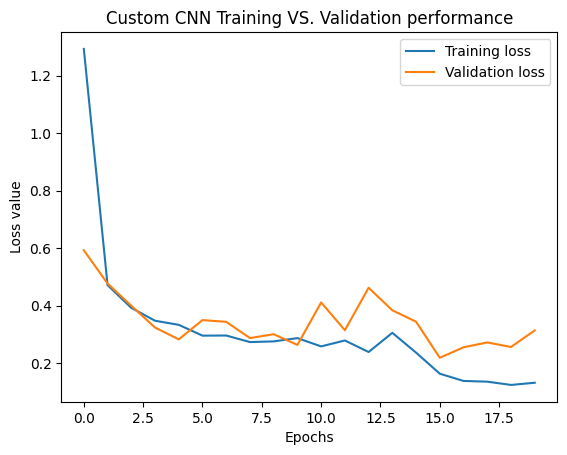

In [17]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss value')
plt.title("Custom CNN Training VS. Validation performance")
plt.show()

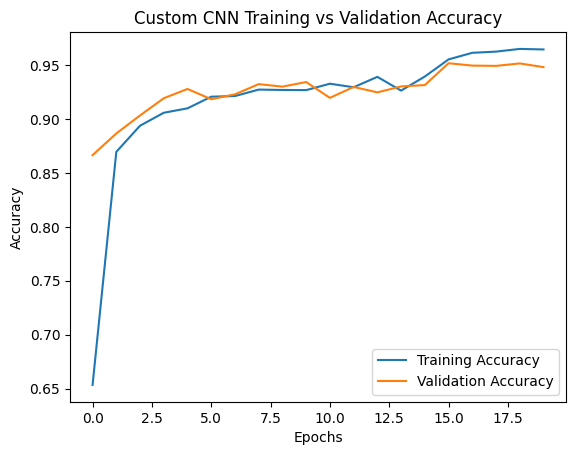

In [115]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Custom CNN Training vs Validation Accuracy')
plt.legend()
plt.show()

In [18]:
# Making a prediction out of the Custom CNN for the testing set for the evaluation
prediction = CNN_model.predict(test_gen)
pred = list(map(lambda x: mapping_inverse[np.argmax(x)], prediction))
y_test = list(map(lambda x: mapping_inverse[x],test_gen.classes))

799/799 [==============================] - 219s 274ms/step


In [19]:
print('\t\tThe Custom CNN Evaluation Performance')
print(classification_report(y_test, pred))

		The Custom CNN Evaluation Performance
              precision    recall  f1-score   support

           a       0.94      0.94      0.94       992
           b       0.97      0.95      0.96       929
           c       0.96      0.92      0.94      1008
           d       0.97      0.97      0.97       999
           e       0.92      0.93      0.93       973
           f       0.99      0.94      0.96      1000
           g       0.96      0.95      0.95       957
           h       0.95      0.95      0.95       973
           i       0.96      0.93      0.94       969
           j       0.97      0.98      0.97       931
           k       0.96      0.97      0.97      1000
           l       0.89      0.95      0.92       974
           m       0.93      0.97      0.95      1005
           n       0.90      0.95      0.93       951
           o       0.95      0.93      0.94       951
           p       0.98      0.95      0.97       982
           q       0.97      0.95      0.

## 4.2) EfficientNetB7

In [20]:
# EfficientNetB7 input layers will not be FREEZED
train_layers = EfficientNetB7(include_top=False, input_shape=IMG_SIZE)
EffNetB7 = Sequential()
EffNetB7.add(train_layers)
EffNetB7.add(Flatten())
EffNetB7.add(Dense(1024, activation='selu'))
EffNetB7.add(Dropout(0.2))
EffNetB7.add(Dense(512, activation='selu'))
EffNetB7.add(Dense(len(mapping), activation='softmax'))

258076736/258076736 [==============================] - 1s 0us/step


In [21]:
EffNetB7.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb7 (Functional  (None, 1, 1, 2560)        64097687  
 )                                                               
                                                                 
 flatten_1 (Flatten)         (None, 2560)              0         
                                                                 
 dense_2 (Dense)             (None, 1024)              2622464   
                                                                 
 dropout_2 (Dropout)         (None, 1024)              0         
                                                                 
 dense_3 (Dense)             (None, 512)               524800    
                                                                 
 dense_4 (Dense)             (None, 26)                13338     
                                                      

In [22]:
# The pre-defined optimizer will be used with too small learning rate
EffNetB7.compile(optimizer=opt, loss=loss, metrics=['accuracy'])

In [23]:
history2 = EffNetB7.fit(train_gen, epochs=EPOCHS, validation_data=valid_gen, callbacks=clbck("EfficientNetB7"))

Epoch 1/10


2025-01-18 11:44:05.528996: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/efficientnetb7/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1398/1398 [==============================] - ETA: 0s - loss: 2.5679 - accuracy: 0.2792
Epoch 1: val_loss improved from inf to 2.22451, saving model to EfficientNetB7_model.h5


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1398/1398 [==============================] - 371s 175ms/step - loss: 2.5679 - accuracy: 0.2792 - val_loss: 2.2245 - val_accuracy: 0.3652 - lr: 1.0000e-05
Epoch 2/10
1398/1398 [==============================] - ETA: 0s - loss: 1.4015 - accuracy: 0.6003
Epoch 2: val_loss improved from 2.22451 to 1.34403, saving model to EfficientNetB7_model.h5
1398/1398 [==============================] - 229s 163ms/step - loss: 1.4015 - accuracy: 0.6003 - val_loss: 1.3440 - val_accuracy: 0.6139 - lr: 1.0000e-05
Epoch 3/10
1398/1398 [==============================] - ETA: 0s - loss: 0.9673 - accuracy: 0.7263
Epoch 3: val_loss improved from 1.34403 to 0.90469, saving model to EfficientNetB7_model.h5
1398/1398 [==============================] - 229s 163ms/step - loss: 0.9673 - accuracy: 0.7263 - val_loss: 0.9047 - val_accuracy: 0.7459 - lr: 1.0000e-05
Epoch 4/10
1398/1398 [==============================] - ETA: 0s - loss: 0.7482 - accuracy: 0.7888
Epoch 4: val_loss improved from 0.90469 to 0.58969, saving m

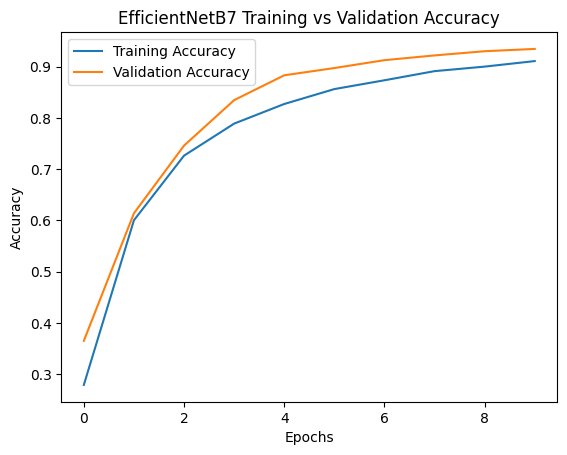

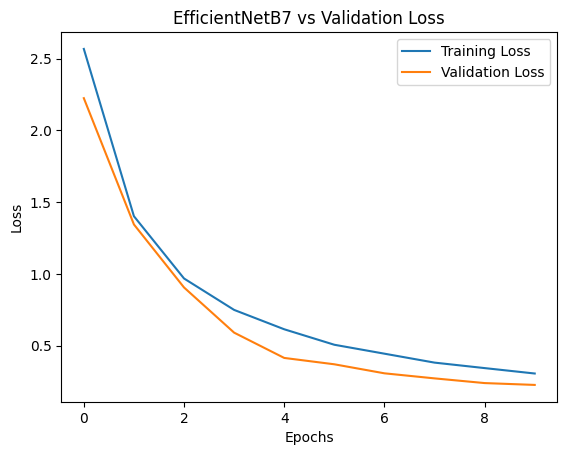

In [113]:
# Plot training and validation accuracy
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('EfficientNetB7 Training vs Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('EfficientNetB7 vs Validation Loss')
plt.legend()
plt.show()


In [25]:
# Making a prediction out of the EfficientNetB7 for the testing set for the evaluation
prediction = EffNetB7.predict(test_gen)
pred = list(map(lambda x: mapping_inverse[np.argmax(x)], prediction))
y_test = list(map(lambda x: mapping_inverse[x],test_gen.classes))

799/799 [==============================] - 78s 92ms/step


In [26]:
print('\t     The EfficientNetB7 Evaluation Performance')
print(classification_report(y_test, pred))

	     The EfficientNetB7 Evaluation Performance
              precision    recall  f1-score   support

           a       0.93      0.92      0.92       992
           b       0.96      0.93      0.94       929
           c       0.94      0.92      0.93      1008
           d       0.97      0.95      0.96       999
           e       0.88      0.90      0.89       973
           f       0.93      0.94      0.93      1000
           g       0.95      0.89      0.92       957
           h       0.95      0.92      0.93       973
           i       0.91      0.90      0.90       969
           j       0.97      0.94      0.95       931
           k       0.88      0.97      0.92      1000
           l       0.87      0.94      0.91       974
           m       0.93      0.97      0.95      1005
           n       0.84      0.92      0.88       951
           o       0.93      0.94      0.93       951
           p       0.96      0.94      0.95       982
           q       0.96      0.93

## 4.3) MobileNetV2

In [37]:
from tensorflow.keras.applications import MobileNetV2

# Create the model
MobileNetV2_model = Sequential()

# Load MobileNetV2 with pre-trained weights, excluding the top classification layer
base_model = MobileNetV2(include_top=False, input_shape=IMG_SIZE, weights='imagenet')

# Freeze the base model layers
base_model.trainable = False

# Add the base model (MobileNetV2)
MobileNetV2_model.add(base_model)

# Add custom layers
MobileNetV2_model.add(Flatten())
MobileNetV2_model.add(Dense(1024, activation='selu'))
MobileNetV2_model.add(Dropout(0.2))
MobileNetV2_model.add(Dense(512, activation='selu'))
MobileNetV2_model.add(Dense(len(mapping), activation='softmax'))  # Final classification layer

# Compile the model
MobileNetV2_model.compile(optimizer=Adam(), loss=loss, metrics=['accuracy'])


In [38]:
# Unfreeze some layers of MobileNetV2
base_model.trainable = True

# Fine-tune the model with a lower learning rate
MobileNetV2_model.compile(optimizer=Adam(learning_rate=1e-5), loss=loss, metrics=['accuracy'])


In [39]:
MobileNetV2_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 1, 1, 1280)        2257984   
 tional)                                                         
                                                                 
 flatten_5 (Flatten)         (None, 1280)              0         
                                                                 
 dense_14 (Dense)            (None, 1024)              1311744   
                                                                 
 dropout_6 (Dropout)         (None, 1024)              0         
                                                                 
 dense_15 (Dense)            (None, 512)               524800    
                                                                 
 dense_16 (Dense)            (None, 26)                13338     
                                                      

In [40]:
# Train the MobileNetV2 model
history3 = MobileNetV2_model.fit(train_gen, epochs=EPOCHS, validation_data=valid_gen, callbacks=clbck("MobileNetV2"))

Epoch 1/10
1398/1398 [==============================] - ETA: 0s - loss: 3.5083 - accuracy: 0.1280

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1398/1398 [==============================] - 203s 126ms/step - loss: 3.5083 - accuracy: 0.1280 - val_loss: 3.3207 - val_accuracy: 0.0588
Epoch 2/10
1398/1398 [==============================] - 120s 86ms/step - loss: 2.6226 - accuracy: 0.2743 - val_loss: 2.7995 - val_accuracy: 0.2058
Epoch 3/10
1398/1398 [==============================] - 129s 92ms/step - loss: 2.2231 - accuracy: 0.3681 - val_loss: 2.1027 - val_accuracy: 0.3932
Epoch 4/10
1398/1398 [==============================] - 174s 124ms/step - loss: 1.9564 - accuracy: 0.4341 - val_loss: 1.8348 - val_accuracy: 0.4577
Epoch 5/10
1398/1398 [==============================] - 149s 107ms/step - loss: 1.7528 - accuracy: 0.4885 - val_loss: 1.5769 - val_accuracy: 0.5275
Epoch 6/10
1398/1398 [==============================] - 121s 86ms/step - loss: 1.5836 - accuracy: 0.5363 - val_loss: 1.3929 - val_accuracy: 0.5799
Epoch 7/10
1398/1398 [==============================] - 109s 78ms/step - loss: 1.4457 - accuracy: 0.5750 - val_loss: 1.2810 - 

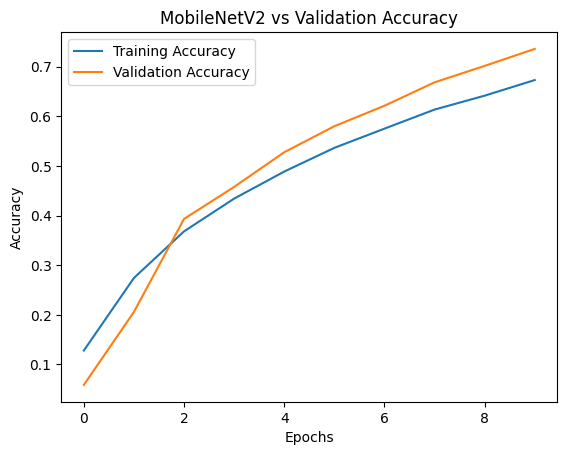

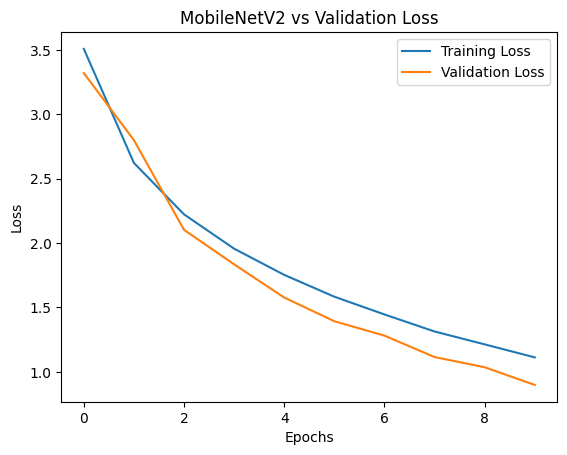

In [116]:
# Plot training and validation accuracy
plt.plot(history3.history['accuracy'], label='Training Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('MobileNetV2 vs Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MobileNetV2 vs Validation Loss')
plt.legend()
plt.show()


In [43]:
# Making a prediction out of the MobileNetV2 for the testing set for the evaluation
prediction = MobileNetV2_model.predict(test_gen)
pred = list(map(lambda x: mapping_inverse[np.argmax(x)], prediction))
y_test = list(map(lambda x: mapping_inverse[x],test_gen.classes))

799/799 [==============================] - 68s 84ms/step


In [46]:
print('\t     The MobileNetV2 Evaluation Performance')
print(classification_report(y_test, pred))

	     The MobileNetV2 Evaluation Performance
              precision    recall  f1-score   support

           a       0.57      0.69      0.62       992
           b       0.76      0.65      0.70       929
           c       0.67      0.57      0.62      1008
           d       0.76      0.67      0.71       999
           e       0.72      0.64      0.68       973
           f       0.78      0.65      0.71      1000
           g       0.76      0.76      0.76       957
           h       0.74      0.69      0.71       973
           i       0.55      0.77      0.64       969
           j       0.79      0.76      0.78       931
           k       0.81      0.85      0.83      1000
           l       0.72      0.76      0.74       974
           m       0.76      0.90      0.82      1005
           n       0.71      0.59      0.65       951
           o       0.69      0.84      0.76       951
           p       0.76      0.78      0.77       982
           q       0.63      0.56   

## 4.4) VGG19

In [47]:
# VGG19 input layers will not be FREEZED
train_layers = VGG19(include_top=False, input_shape=IMG_SIZE)
VG = Sequential()
VG.add(train_layers)
VG.add(Flatten())
VG.add(Dense(1024, activation='selu'))
VG.add(Dense(512, activation='selu'))
VG.add(Dense(len(mapping), activation='softmax'))

80134624/80134624 [==============================] - 1s 0us/step


In [48]:
VG.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 1, 1, 512)         20024384  
                                                                 
 flatten_6 (Flatten)         (None, 512)               0         
                                                                 
 dense_17 (Dense)            (None, 1024)              525312    
                                                                 
 dense_18 (Dense)            (None, 512)               524800    
                                                                 
 dense_19 (Dense)            (None, 26)                13338     
                                                                 
Total params: 21087834 (80.44 MB)
Trainable params: 21087834 (80.44 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [51]:
VG.compile(optimizer=Adam(learning_rate=0.00001, epsilon=1e-6), loss=loss, metrics=['accuracy'])

In [52]:
history4 = VG.fit(train_gen, validation_data=valid_gen, epochs=EPOCHS, callbacks=clbck('VGG19'))

Epoch 1/10
1398/1398 [==============================] - ETA: 0s - loss: 0.7325 - accuracy: 0.8293

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1398/1398 [==============================] - 147s 100ms/step - loss: 0.7325 - accuracy: 0.8293 - val_loss: 0.3651 - val_accuracy: 0.9131
Epoch 2/10
1398/1398 [==============================] - 100s 72ms/step - loss: 0.2658 - accuracy: 0.9298 - val_loss: 0.2282 - val_accuracy: 0.9417
Epoch 3/10
1398/1398 [==============================] - 99s 71ms/step - loss: 0.1913 - accuracy: 0.9463 - val_loss: 0.2106 - val_accuracy: 0.9469
Epoch 4/10
1398/1398 [==============================] - 112s 80ms/step - loss: 0.1581 - accuracy: 0.9547 - val_loss: 0.2049 - val_accuracy: 0.9483
Epoch 5/10
1398/1398 [==============================] - 102s 73ms/step - loss: 0.1375 - accuracy: 0.9596 - val_loss: 0.1986 - val_accuracy: 0.9537
Epoch 6/10
1398/1398 [==============================] - 102s 73ms/step - loss: 0.1194 - accuracy: 0.9640 - val_loss: 0.1722 - val_accuracy: 0.9588
Epoch 7/10
1398/1398 [==============================] - 101s 72ms/step - loss: 0.1046 - accuracy: 0.9688 - val_loss: 0.1934 - val

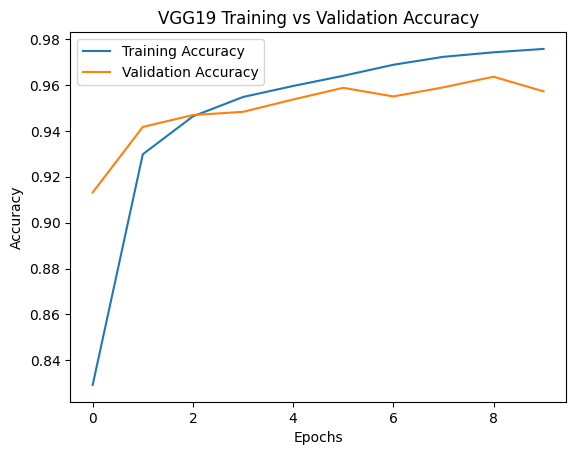

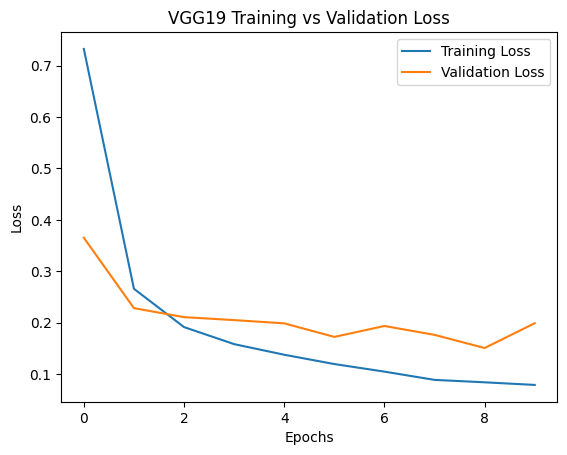

In [117]:
plt.plot(history4.history['accuracy'], label='Training Accuracy')
plt.plot(history4.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('VGG19 Training vs Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history4.history['loss'], label='Training Loss')
plt.plot(history4.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('VGG19 Training vs Validation Loss')
plt.legend()
plt.show()


In [54]:
# Making a prediction out of the VGG19 for the testing set for the evaluation
prediction = VG.predict(test_gen)
pred = list(map(lambda x: mapping_inverse[np.argmax(x)], prediction))
y_test = list(map(lambda x: mapping_inverse[x],test_gen.classes))

799/799 [==============================] - 70s 87ms/step


In [55]:
print('\t\tThe VGG19 Evaluation Performance')
print(classification_report(y_test, pred))

		The VGG19 Evaluation Performance
              precision    recall  f1-score   support

           a       0.90      0.96      0.93       992
           b       0.98      0.97      0.97       929
           c       0.96      0.93      0.94      1008
           d       0.94      0.99      0.96       999
           e       0.98      0.89      0.93       973
           f       0.97      0.95      0.96      1000
           g       0.94      0.95      0.94       957
           h       0.95      0.97      0.96       973
           i       0.99      0.85      0.92       969
           j       0.92      0.98      0.95       931
           k       0.98      0.98      0.98      1000
           l       0.91      0.98      0.94       974
           m       0.98      0.97      0.98      1005
           n       0.90      0.97      0.93       951
           o       0.96      0.94      0.95       951
           p       0.97      0.98      0.98       982
           q       0.90      0.99      0.94   

## 4.5) DenseNet121 

In [56]:
# DenseNset121 input layers will not be FREEZED
train_layers = DenseNet121(include_top=False, input_shape=IMG_SIZE)
Den = Sequential()
Den.add(train_layers)
Den.add(Flatten())
Den.add(Dense(1024, activation='selu'))
Den.add(Dense(512, activation='selu'))
Den.add(Dense(len(mapping), activation='softmax'))

29084464/29084464 [==============================] - 0s 0us/step


In [57]:
Den.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 1, 1, 1024)        7037504   
                                                                 
 flatten_7 (Flatten)         (None, 1024)              0         
                                                                 
 dense_20 (Dense)            (None, 1024)              1049600   
                                                                 
 dense_21 (Dense)            (None, 512)               524800    
                                                                 
 dense_22 (Dense)            (None, 26)                13338     
                                                                 
Total params: 8625242 (32.90 MB)
Trainable params: 8541594 (32.58 MB)
Non-trainable params: 83648 (326.75 KB)
_________________________________________________________________


In [60]:
Den.compile(optimizer=Adam(learning_rate=0.00001, epsilon=1e-6), loss=loss, metrics=['accuracy'])

In [61]:
history5 = Den.fit(train_gen, validation_data=valid_gen, epochs=10, callbacks=clbck("DenseNet121"))

Epoch 1/10
1398/1398 [==============================] - ETA: 0s - loss: 1.7770 - accuracy: 0.5182

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1398/1398 [==============================] - 219s 112ms/step - loss: 1.7770 - accuracy: 0.5182 - val_loss: 0.7651 - val_accuracy: 0.7913
Epoch 2/10
1398/1398 [==============================] - 135s 97ms/step - loss: 0.7755 - accuracy: 0.7830 - val_loss: 0.4756 - val_accuracy: 0.8687
Epoch 3/10
1398/1398 [==============================] - 134s 96ms/step - loss: 0.5449 - accuracy: 0.8449 - val_loss: 0.3463 - val_accuracy: 0.9023
Epoch 4/10
1398/1398 [==============================] - 134s 96ms/step - loss: 0.4263 - accuracy: 0.8775 - val_loss: 0.2988 - val_accuracy: 0.9148
Epoch 5/10
1398/1398 [==============================] - 134s 96ms/step - loss: 0.3546 - accuracy: 0.8980 - val_loss: 0.2385 - val_accuracy: 0.9290
Epoch 6/10
1398/1398 [==============================] - 133s 95ms/step - loss: 0.3087 - accuracy: 0.9110 - val_loss: 0.2182 - val_accuracy: 0.9369
Epoch 7/10
1398/1398 [==============================] - 134s 96ms/step - loss: 0.2599 - accuracy: 0.9232 - val_loss: 0.2248 - va

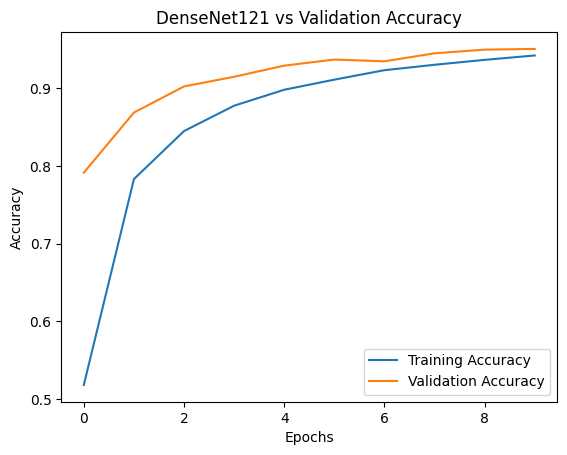

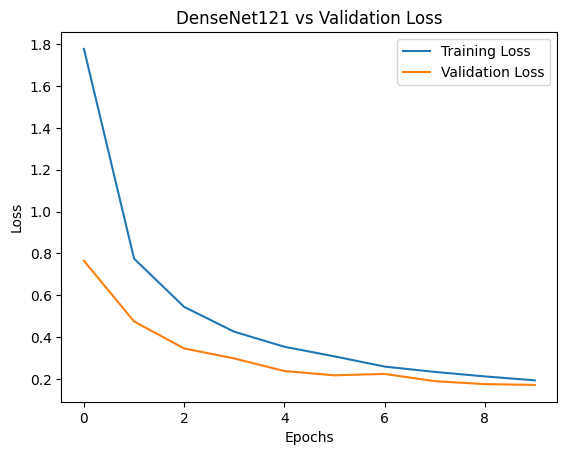

In [119]:
plt.plot(history5.history['accuracy'], label='Training Accuracy')
plt.plot(history5.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('DenseNet121 vs Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history5.history['loss'], label='Training Loss')
plt.plot(history5.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('DenseNet121 vs Validation Loss')
plt.legend()
plt.show()


In [63]:
# Making a prediction out of the DenseNet121 for the testing set for the evaluation
prediction = Den.predict(test_gen)
pred = list(map(lambda x: mapping_inverse[np.argmax(x)], prediction))
y_test = list(map(lambda x: mapping_inverse[x],test_gen.classes))

799/799 [==============================] - 65s 79ms/step


In [64]:
print('\t\tThe DenseNet121 Evaluation Performance')
print(classification_report(y_test, pred))

		The DenseNet121 Evaluation Performance
              precision    recall  f1-score   support

           a       0.89      0.94      0.92       992
           b       0.97      0.96      0.96       929
           c       0.92      0.94      0.93      1008
           d       0.97      0.96      0.96       999
           e       0.93      0.91      0.92       973
           f       0.98      0.94      0.96      1000
           g       0.95      0.93      0.94       957
           h       0.95      0.96      0.95       973
           i       0.97      0.91      0.94       969
           j       0.96      0.96      0.96       931
           k       0.96      0.96      0.96      1000
           l       0.94      0.93      0.94       974
           m       0.95      0.97      0.96      1005
           n       0.93      0.95      0.94       951
           o       0.97      0.94      0.95       951
           p       0.97      0.96      0.96       982
           q       0.93      0.97      0

## 4.6)ResNet

In [100]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

# ResNet50 input layers will not be FREEZED
train_layers = ResNet50(include_top=False, input_shape=IMG_SIZE)

Res = Sequential()
Res.add(train_layers)
Res.add(Flatten())
Res.add(Dense(1024, activation='selu'))
Res.add(Dense(512, activation='selu'))
Res.add(Dense(len(mapping), activation='softmax'))

In [101]:
# Compile the model
Res.compile(optimizer=Adam(learning_rate=0.00001, epsilon=1e-6), loss=loss, metrics=['accuracy'])

In [102]:
# Train the model
history6 = Res.fit(train_gen, validation_data=valid_gen, epochs=10, callbacks=clbck("ResNet50"))

Epoch 1/10
1398/1398 [==============================] - ETA: 0s - loss: 2.0528 - accuracy: 0.4641

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1398/1398 [==============================] - 188s 110ms/step - loss: 2.0528 - accuracy: 0.4641 - val_loss: 1.1408 - val_accuracy: 0.6836
Epoch 2/10
1398/1398 [==============================] - 101s 72ms/step - loss: 0.9277 - accuracy: 0.7396 - val_loss: 0.6667 - val_accuracy: 0.8109
Epoch 3/10
1398/1398 [==============================] - 102s 73ms/step - loss: 0.6519 - accuracy: 0.8148 - val_loss: 0.4724 - val_accuracy: 0.8675
Epoch 4/10
1398/1398 [==============================] - 104s 75ms/step - loss: 0.5065 - accuracy: 0.8542 - val_loss: 0.3894 - val_accuracy: 0.8887
Epoch 5/10
1398/1398 [==============================] - 105s 75ms/step - loss: 0.4113 - accuracy: 0.8804 - val_loss: 0.3144 - val_accuracy: 0.9101
Epoch 6/10
1398/1398 [==============================] - 106s 75ms/step - loss: 0.3533 - accuracy: 0.8952 - val_loss: 0.2785 - val_accuracy: 0.9191
Epoch 7/10
1398/1398 [==============================] - 106s 76ms/step - loss: 0.3059 - accuracy: 0.9103 - val_loss: 0.2618 - va

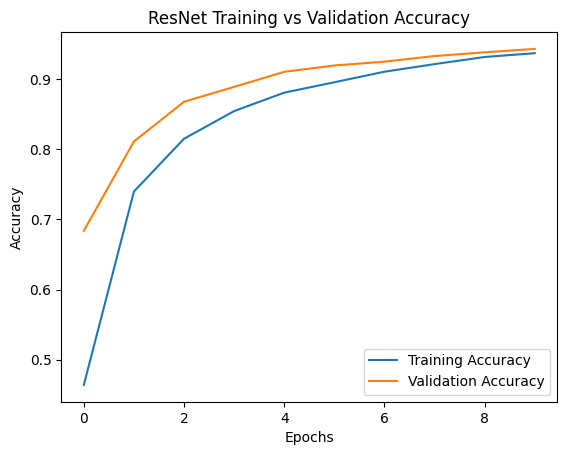

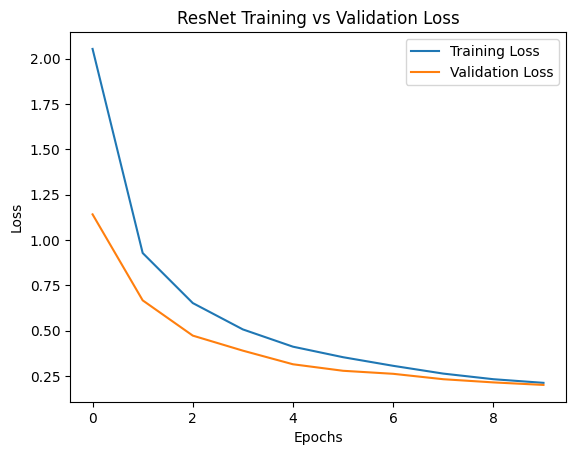

In [120]:
plt.plot(history6.history['accuracy'], label='Training Accuracy')
plt.plot(history6.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet Training vs Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history6.history['loss'], label='Training Loss')
plt.plot(history6.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet Training vs Validation Loss')
plt.legend()
plt.show()


In [104]:
prediction = Res.predict(test_gen)
pred = list(map(lambda x: mapping_inverse[np.argmax(x)], prediction))
y_test = list(map(lambda x: mapping_inverse[x],test_gen.classes))

799/799 [==============================] - 65s 81ms/step


In [105]:
print('\t\tThe ResNet Evaluation Performance')
print(classification_report(y_test, pred))

		The ResNet Evaluation Performance
              precision    recall  f1-score   support

           a       0.88      0.93      0.90       992
           b       0.96      0.95      0.95       929
           c       0.90      0.93      0.92      1008
           d       0.96      0.95      0.96       999
           e       0.93      0.90      0.92       973
           f       0.96      0.95      0.95      1000
           g       0.95      0.92      0.93       957
           h       0.93      0.95      0.94       973
           i       0.96      0.91      0.93       969
           j       0.97      0.95      0.96       931
           k       0.94      0.96      0.95      1000
           l       0.90      0.94      0.92       974
           m       0.95      0.96      0.95      1005
           n       0.93      0.93      0.93       951
           o       0.90      0.95      0.93       951
           p       0.96      0.94      0.95       982
           q       0.96      0.95      0.96  

# 5) Evaluation & Comparison

In [121]:
vals = {'accuracy':[0.95,0.93,0.71,0.96,0.95,0.94], 'precision':[0.96,0.94,0.72,0.96,0.95,0.94],
       'recall':[0.95,0.93,0.71,0.96,0.95,0.94], 'F1-Score':[0.95,0.93,0.71,0.96,0.95,0.94]}
results = pd.DataFrame(vals, index=['Custom CNN','EfficientNetB7','MobileNetV7','VGG19',
                                   'DenseNet121','ResNet'])

print("\t\tThe Evaluation results of CNN/Pre-trained models")
print(results)

		The Evaluation results of CNN/Pre-trained models
                accuracy  precision  recall  F1-Score
Custom CNN          0.95       0.96    0.95      0.95
EfficientNetB7      0.93       0.94    0.93      0.93
MobileNetV7         0.71       0.72    0.71      0.71
VGG19               0.96       0.96    0.96      0.96
DenseNet121         0.95       0.95    0.95      0.95
ResNet              0.94       0.94    0.94      0.94


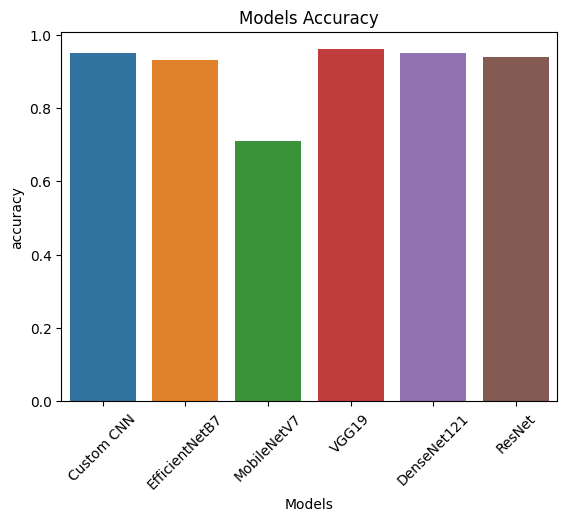

In [122]:
sns.barplot(data=results, x=results.index, y='accuracy')
plt.xticks(rotation=45)
plt.xlabel('Models')
plt.title("Models Accuracy")
plt.show()

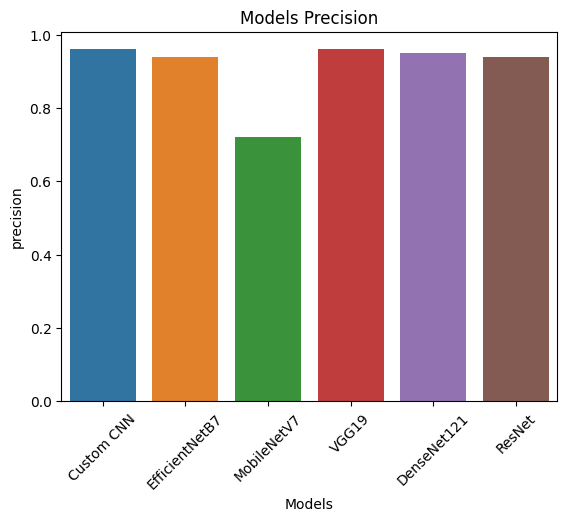

In [123]:
sns.barplot(data=results, x=results.index, y='precision')
plt.xticks(rotation=45)
plt.xlabel('Models')
plt.title("Models Precision")
plt.show()

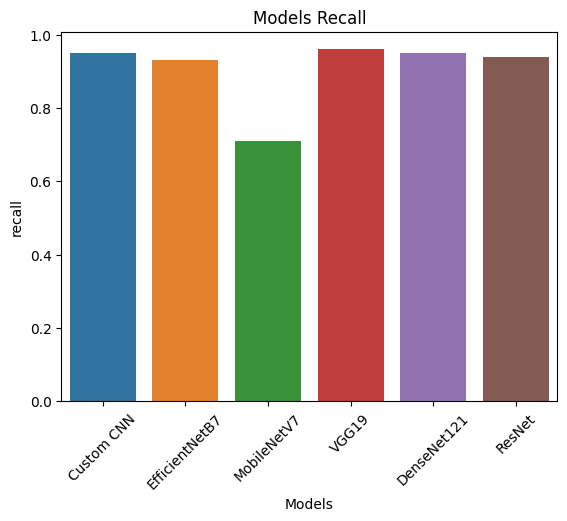

In [124]:
sns.barplot(data=results, x=results.index, y='recall')
plt.xticks(rotation=45)
plt.xlabel('Models')
plt.title("Models Recall")
plt.show()

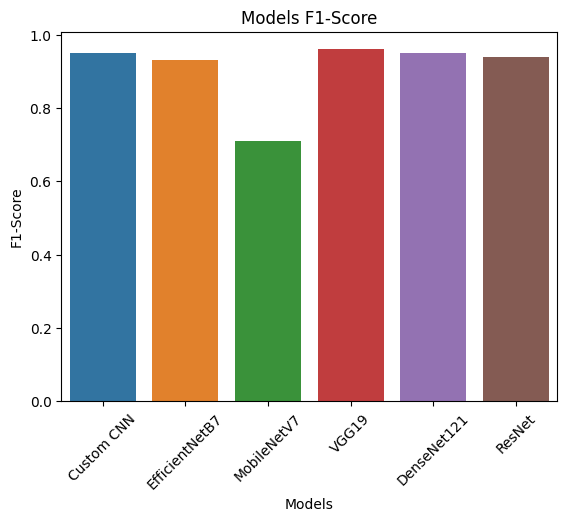

In [125]:
sns.barplot(data=results, x=results.index, y='F1-Score')
plt.xticks(rotation=45)
plt.xlabel('Models')
plt.title("Models F1-Score")
plt.show()

In [127]:
import os
print(os.listdir())

['ResNet50_best.h5', '.virtual_documents', 'MobileNetV2_best.h5', 'CustomCnn_model.h5', 'EfficientNetB7_model.h5', 'VGG19_best.h5', 'DenseNet121_best.h5']


In [136]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.applications.densenet import preprocess_input

# Function to read and preprocess the image
def read_image(image_path):
    """
    Reads an image and converts it to RGB format.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def preprocess_image(img):
    """
    Preprocess the image for DenseNet121 model input.
    """
    img = cv2.resize(img, (32, 32))  # Resize to match DenseNet121 input size
    img = preprocess_input(img)  # Normalize for DenseNet121
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Function to predict and display results
def extract_and_show(image_path):
    """
    Predicts the label for the input image and displays the image alongside the result.
    """
    img = read_image(image_path)  # Read the image
    processed_img = preprocess_image(img)  # Preprocess for model
    predictions = model.predict(processed_img)  # Predict with DenseNet121
    predicted_class = np.argmax(predictions, axis=1)  # Get class index
    predicted_label = mapping_inverse[predicted_class[0]]  # Map class index to label
    
    # Display the image with the predicted label
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted Label: {predicted_label}")
    plt.show()
    
    return predicted_label


## 6.1) Testing

1/1 [==============================] - 0s 29ms/step


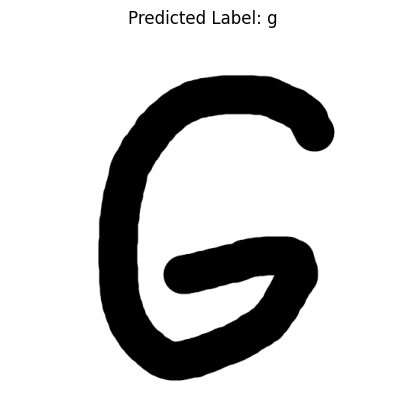

Predicted Text = g


In [140]:
image_path1 = '/kaggle/input/drawtestdata/Screenshot 2025-01-18 195527.png'
result1 = extract_and_show(image_path1)
print("Predicted Text =", result1)